In [1]:
import os
import yaml
import h5py
import numpy as np
import matplotlib.pyplot as plt
from gw_anomaly_detection.data.segments import SegmentInfo
from gw_anomaly_detection.data.s3_utils import S3_session
from gw_anomaly_detection.data.waveforms import Waveforms
from gw_anomaly_detection.data.process import Process


In [2]:
os.chdir('/home/chiajui/gw-anomaly-detection')
print(os.getcwd())

/home/chiajui/gw-anomaly-detection


### Loading data_config.yaml

In [3]:
with open("./data_config.yaml", "r") as file:
    config = yaml.safe_load(file)

ifos = config['data']['ifos']
data_cache = config['data']['data_cache']
asd_cache = config['data']['asd_cache']
injection = config['data']['injection']
output_dir = config['data']['output_dir']
keep_waveform = config['data']['gw_anomaly']['keep_waveform']

### Loading the information of the target segments.

In [4]:
background_segment_files = dict.fromkeys(ifos)
glitch_segment_files = dict.fromkeys(ifos)
bg_segs = dict.fromkeys(ifos)
glitch_segs = dict.fromkeys(ifos)
interval = dict.fromkeys(ifos)
bg_seg_files = {
    "H1": ["/home/chiajui/gw-anomaly-detection/segments/O3a/H1-test-1238172987-23806.segwizard"], 
    "L1":  ["/home/chiajui/gw-anomaly-detection/segments/O3a/L1-test-1238205073-23812.segwizard"],
}
for ifo in ifos:
    seg_info = SegmentInfo(ifo)
    bg_segs[ifo] = seg_info.read_segment_files(bg_seg_files[ifo])
    interval[ifo] = seg_info.whole_segment(bg_seg_files[ifo])

    print(f"Number of background segments from {ifo}: {len(bg_segs[ifo])}, interval: {interval[ifo]}.")

Number of background segments from H1: 3, interval: (1238174042, 1238183615).
Number of background segments from L1: 3, interval: (1238207182, 1238216822).


### Generating Waveform.

In [5]:
waveform = config['data']['gw_anomaly']['waveform']
qm_file = config['data']['gw_anomaly']['qm_file']
sampling_frequency = config['data']['gw_anomaly']['sampling_frequency']
length = config['data']['gw_anomaly']['length']
number = 3
wav = Waveforms(
    ifos=ifos,
    length=length,
    sampling_frequency=sampling_frequency,
)
waveforms, params = wav.generate_waveforms(
    waveform,
    number,
    qm_file=qm_file,
)

In [6]:
# from pycbc.types.timeseries import TimeSeries as pycbcts
# from pycbc.detector import Detector
# from gwpy.timeseries import TimeSeries

# with h5py.File(qm_file, 'r') as f:
#     times = f['time'][:]
#     qm = f['quad_moment'][:]

# print(len(times))
# ifo = 'H1'
# id = 0
# length = 4
# theta = params[id]['theta']
# phi = params[id]['phi']
# hp =\
#     qm[:,0,0]*(np.cos(theta)**2*np.cos(phi)**2 - np.sin(phi)**2).reshape(-1, 1)\
#     + qm[:,1,1]*(np.cos(theta)**2*np.sin(phi)**2 - np.cos(phi)**2).reshape(-1, 1)\
#     + qm[:,2,2]*(np.sin(theta)**2).reshape(-1, 1)\
#     + qm[:,0,1]*(np.cos(theta)**2*np.sin(2*phi) - np.sin(2*phi)).reshape(-1, 1)\
#     - qm[:,1,2]*(np.sin(2*theta)*np.sin(phi)).reshape(-1, 1)\
#     - qm[:,2,0]*(np.sin(2*theta)*np.cos(phi)).reshape(-1, 1)
# hp = pycbcts(hp[0], delta_t=1/sampling_frequency, epoch=times[0])
# print(len(hp))
# # hp.plot()

# hc = 2*(
#     - qm[:,0,0]*(np.cos(theta)*np.sin(phi)*np.cos(phi)).reshape(-1, 1)
#     + qm[:,1,1]*(np.cos(theta)*np.sin(phi)*np.cos(phi)).reshape(-1, 1)
#     + qm[:,0,1]*(np.cos(theta)*np.cos(2*phi)).reshape(-1, 1)
#     - qm[:,1,2]*(np.sin(theta)*np.cos(phi)).reshape(-1, 1)
#     + qm[:,2,0]*(np.sin(theta)*np.sin(phi)).reshape(-1, 1)
# )
# hc = pycbcts(hc[0], delta_t=1/sampling_frequency, epoch=times[0])
# print(len(hc))
# # hc.plot()

# signal = Detector(ifo).project_wave(
#     hp=hp,
#     hc=hc,
#     ra=params[id]['ra'],
#     dec=params[id]['dec'],
#     polarization=params[id]['psi'],
# )
# print(len(signal))
# # signal.plot()

# st = signal.sample_times[0] - signal.sample_times[0]%(1/sampling_frequency)
# ed = signal.sample_times[-1] - signal.sample_times[-1]%(1/sampling_frequency)
# plength = int((st - -length/2)*sampling_frequency)
# nlength = int((ed - length/2)*sampling_frequency)
# print(st, ed, plength, nlength)

# if plength >= 0:
#     pad_signal = np.pad(signal.numpy(), (plength, 0), constant_values=(0, 0))
# if plength < 0:
#     pad_signal = signal.numpy()
#     pad_signal = pad_signal[-plength:]
# if nlength <= 0:
#     pad_signal = np.pad(pad_signal, (0, -nlength), constant_values=(0, 0))
# if nlength > 0:
#     pad_signal = pad_signal[:length*sampling_frequency]

# t0 = 0
# signal_ts = TimeSeries(
#     pad_signal,
#     name=f'{ifo}:CCSN_SIG',
#     channel=f'{ifo}:CCSN_SIG',
#     sample_rate=sampling_frequency,
#     t0=t0,
# )
# print(signal_ts.t0, signal_ts.duration)
# # signal_ts = signal_ts.crop(signal_ts.times[1], signal_ts.times[-1])

In [7]:
# print(signal_ts.duration)
# if (signal_ts.duration.value > 4):
#     print("Crop!")
#     crop_ed = -int((signal_ts.duration.value - length)*signal_ts.sample_rate.value)
#     signal_ts = signal_ts.crop(end=signal_ts.times[crop_ed])
# if (signal_ts.duration.value < 4):
#     print("Pad!")
#     pad_width = (int((length - signal_ts.duration.value)*signal_ts.sample_rate.value), 0)
#     signal_ts = signal_ts.pad(pad_width)

# print(signal_ts.duration)
# signal_ts.plot().show()

TimeSeries([0., 0., 0., ..., 0., 0., 0.]
           unit: dimensionless,
           t0: 0.0 s,
           dt: 6.103515625e-05 s,
           name: H1:CCSN_SIG,
           channel: H1:CCSN_SIG)
4.0 s
TimeSeries([0., 0., 0., ..., 0., 0., 0.]
           unit: dimensionless,
           t0: 0.0 s,
           dt: 6.103515625e-05 s,
           name: L1:CCSN_SIG,
           channel: L1:CCSN_SIG)
4.0 s


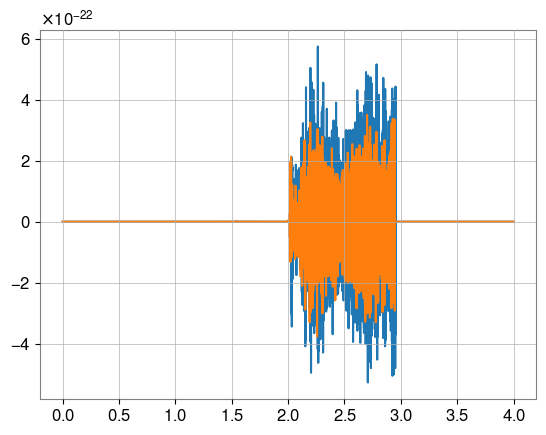

In [8]:
id = 1
print(waveforms[id]['H1'])
print(waveforms[id]['H1'].duration)
print(waveforms[id]['L1'])
print(waveforms[id]['L1'].duration)
plt.figure()
plt.plot(waveforms[id]['H1'])
plt.plot(waveforms[id]['L1'])
plt.show()

### Rescaling and Injection

In [9]:
flow = config['data']['processing']['flow']
fhigh = config['data']['processing']['fhigh']
resample = config['data']['processing']['resample']
crop_length = config['data']['processing']['crop_length']
target_snr_low = config['data']['gw_anomaly']['target_snr_low']
target_snr_high = config['data']['gw_anomaly']['target_snr_high']
proc = Process(
    ifos=ifos,
    data_cache=data_cache,
    asd_cache=asd_cache,
)
injected_ts, rescaled_waveforms, snrs = proc.inject(
    waveforms=waveforms,
    target_snr_low=target_snr_low,
    target_snr_high=target_snr_high,
    background_segments=bg_segs,
)

### Processing data.

In [10]:
timeseries = injected_ts
processed_data = proc.get_proccessed_data(
    timeseries=timeseries,
    background_segments=bg_segs,
    flow=flow,
    fhigh=fhigh,
    resample=resample,
    crop_length=crop_length,
    method=1,
)
timeseries = rescaled_waveforms
processed_waveforms = proc.get_proccessed_data(
    timeseries=timeseries,
    background_segments=bg_segs,
    flow=flow,
    fhigh=fhigh,
    resample=resample,
    crop_length=crop_length,
    method=1,
)
# processed_data_2 = proc.get_proccessed_data(
#     timeseries=injected_ts,
#     background_segments=bg_segs,
#     flow=flow,
#     fhigh=fhigh,
#     resample=resample,
#     crop_length=crop_length,
#     method=2,
# )

### Write data to hdf5 files

In [11]:
print(f"params: {len(params)}")
print(f"waveforms: {len(processed_waveforms)}")
print(f"snrs: {len(snrs)}")
print(f"processed_data: {len(processed_data)}")

print("")
print(waveform)
# print(params[0])
# print(snrs[0])

# Write data to hdf5 files.
param_names = list(params[0].keys())
param_formats = []
for name in param_names:
    if isinstance(params[0][name], float) or isinstance(params[0][name], int):
        param_formats.append('f8')
    if isinstance(params[0][name], str):
        param_formats.append(h5py.string_dtype(encoding="ascii"))

snr_names = list(snrs[0].keys())
snr_formats = ['f8' for i in range(len(snr_names))]
names = param_names + snr_names
formats = param_formats + snr_formats
dt = np.dtype({'names': names, 'formats': formats})
param_data = np.array(
    [tuple(param.values()) + tuple(snr.values())
        for param, snr in zip(params, snrs)],
    dtype=dt,
)

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

with h5py.File(f"{output_dir}/test_data.hdf5", 'w') as w:
    w.create_dataset(
        'waveform_parameters',
        shape=param_data.shape,
        dtype=dt,
        data=param_data,
    )

    print(processed_data[0]['H1'])
    ifos = list(processed_data[0].keys())
    proc_data = dict.fromkeys(ifos)
    t0_data = dict.fromkeys(ifos)
    for ifo in ifos:
        proc_data[ifo] = np.array([data[ifo] for data in processed_data])
        t0_data[ifo] = np.array([data[ifo].t0.value for data in processed_data])
        sample_rate = processed_data[0][ifo].sample_rate.value
        print(proc_data[ifo][0])
        proc_dset = w.create_dataset(
            ifo,
            shape=proc_data[ifo].shape,
            dtype=proc_data[ifo].dtype,
            data=proc_data[ifo]
        )
        proc_dset.attrs['sample_rate'] = sample_rate
        w.create_dataset(
            f"t0_{ifo}",
            shape=t0_data[ifo].shape,
            dtype=t0_data[ifo].dtype,
            data=t0_data[ifo]
        )

    if keep_waveform:
        print(processed_waveforms[0]['H1'])
        ifos = list(processed_waveforms[0].keys())
        waveform_data = dict.fromkeys(ifos)
        for ifo in ifos:
            waveform_data[ifo] = np.array([waveform[ifo] for waveform in processed_waveforms])
            channel = str(processed_waveforms[0][ifo].channel)
            print(waveform_data[ifo][0])
            waveform_dset = w.create_dataset(
                f"waveform_{ifo}",
                shape=waveform_data[ifo].shape,
                dtype=waveform_data[ifo].dtype,
                data=waveform_data[ifo]
            )
            waveform_dset.attrs['channel'] = channel


params: 3
waveforms: 3
snrs: 3
processed_data: 3

ccsn
TimeSeries([-0.30872684,  0.42246021,  0.41395777, ...,
            -0.15486306,  0.21201086,  1.51000632]
           unit: dimensionless,
           t0: 1238174043.9917603 s,
           dt: 0.000244140625 s,
           name: Strain,
           channel: None)
[-0.30872684  0.42246021  0.41395777 ... -0.15486306  0.21201086
  1.51000632]
[-0.29224383  0.78898849  0.75128517 ... -0.12944234  0.799715
  0.04349749]
TimeSeries([ 3.52996877e-08,  1.18966351e-08, -6.48395559e-09,
            ...,  1.50203883e-04, -6.05186194e-04,
            -3.13489949e-04]
           unit: dimensionless,
           t0: 1238174043.9917603 s,
           dt: 0.000244140625 s,
           name: H1:CCSN_SIG,
           channel: H1:CCSN_SIG)
[ 3.52996877e-08  1.18966351e-08 -6.48395559e-09 ...
  1.50203883e-04 -6.05186194e-04 -3.13489949e-04]
[1.47715647e-06 9.72496663e-07 1.79656823e-07 ... 2.12119086e-03
 1.13403766e-03 3.87756883e-04]


<KeysViewHDF5 ['H1', 'L1', 't0_H1', 't0_L1', 'waveform_H1', 'waveform_L1', 'waveform_parameters']>
<HDF5 dataset "waveform_parameters": shape (3,), type "|V96">
('phi', 'theta', 'distance', 'phase', 'ra', 'dec', 'psi', 'simulation', 'qm_file', 'snr_H1', 'snr_L1', 'network_snr')
<HDF5 dataset "t0_H1": shape (3,), type "<f8">
<HDF5 dataset "H1": shape (3, 8192), type "<f8">
4096.0
<HDF5 dataset "waveform_H1": shape (3, 8192), type "<f8">
H1:CCSN_SIG
<HDF5 dataset "t0_L1": shape (3,), type "<f8">
<HDF5 dataset "L1": shape (3, 8192), type "<f8">
4096.0
<HDF5 dataset "waveform_L1": shape (3, 8192), type "<f8">
L1:CCSN_SIG


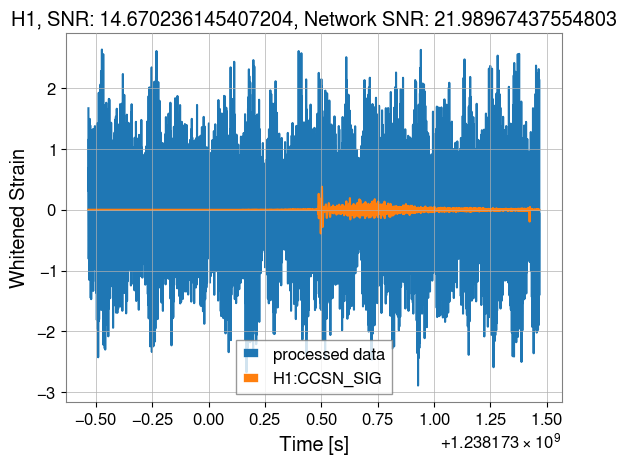

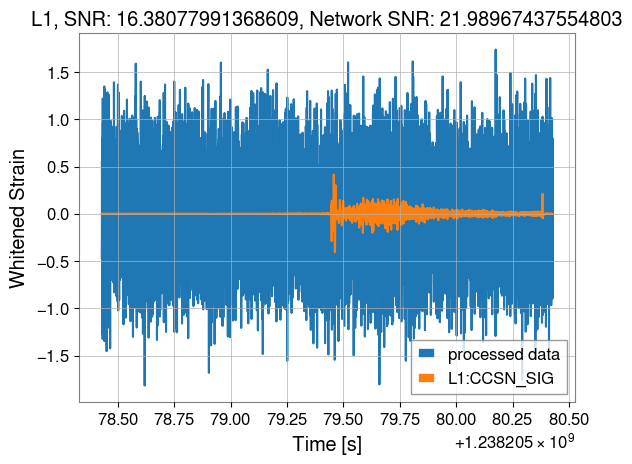

In [16]:
with h5py.File(f"{output_dir}/test_data.hdf5", 'r') as f:
    print(f.keys())
    print(f['waveform_parameters'])
    print(f['waveform_parameters'].dtype.names)
    print(f['t0_H1'])
    print(f['H1'])
    print(f['H1'].attrs['sample_rate'])
    print(f['waveform_H1'])
    print(f['waveform_H1'].attrs['channel'])
    print(f['t0_L1'])
    print(f['L1'])
    print(f['L1'].attrs['sample_rate'])
    print(f['waveform_L1'])
    print(f['waveform_L1'].attrs['channel'])

    id = 0
    for ifo in ifos:
        t0 = f[f't0_{ifo}'][id]
        sample_rate = f[ifo].attrs['sample_rate']
        times = np.arange(t0, t0+2, 1/sample_rate)
        waveform = f[f"waveform_{ifo}"].attrs['channel']
        snr = f['waveform_parameters'][id][f'snr_{ifo}']
        network_snr = f['waveform_parameters'][id][f'network_snr']
        plt.figure()
        plt.title(f"{ifo}, SNR: {snr}, Network SNR: {network_snr}")
        plt.plot(times, f[ifo][id], label='processed data')
        plt.plot(times, f[f'waveform_{ifo}'][id], label=waveform)
        plt.xlabel("Time [s]")
        plt.ylabel("Whitened Strain")
        plt.legend()
        plt.show()

In [13]:
# for i in range(number):
#     # print(processed_data[i])
#     for ifo in ifos:
#         processed_data_1[i][ifo].write(
#             f"test/{ifo}-proc_1_test_{i}.hdf5",
#             format='hdf5',
#         )
#         processed_data_2[i][ifo].write(
#             f"test/{ifo}-proc_2_test_{i}.hdf5",
#             format='hdf5',
#         )

# ifo = "H1"
# ts_1 = TimeSeries.read(f"./test/{ifo}-proc_1_test_0.hdf5", format="hdf5")
# ts_2 = TimeSeries.read(f"./test/{ifo}-proc_2_test_0.hdf5", format="hdf5")

In [14]:
# diff = ts_1 - ts_2
# plt.figure(figsize=[10,4])
# plt.title("Head")
# plt.plot(diff.times[:16], diff[:16], label='diff')
# plt.xlabel("Time [s]")
# plt.ylabel("Strain")
# plt.legend()
# plt.show()

# plt.figure(figsize=[10,4])
# plt.title("Tail")
# plt.plot(diff.times[-16:], diff[-16:], label='diff')
# plt.xlabel("Time [s]")
# plt.ylabel("Strain")
# plt.legend()
# plt.show()